In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
extract_dir = '/content'

In [ ]:
!tar -xf /content/drive/MyDrive/DNN_Dataset/raw_data.tar -C {extract_dir}

In [12]:
!rm -rf /content/raw_data/test

In [5]:
raw_dir = "/content/raw_data"

In [8]:
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import shutil
import os

DATA_ROOT = Path("/content/raw_data")

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR   = DATA_ROOT / "val"

OUT_ROOT = Path("/content/classifier_crops_224")

class_names = {
    1: "swimmer",
    2: "boat",
    3: "jetski",
    4: "life_saving_appliances",
    5: "buoy",
}

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("VAL_DIR exists:", VAL_DIR.exists())

DATA_ROOT exists: True
TRAIN_DIR exists: True
VAL_DIR exists: True


In [10]:
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import shutil
import pandas as pd

# =========================
# CONFIG
# =========================
RAW_ROOT = Path("/content/raw_data")
OUT_ROOT = Path("/content/vit_crops_224")

CLASS_NAMES = {
    1: "swimmer",
    2: "boat",
    3: "jetski",
    4: "life_saving_appliances",
    5: "buoy",
}

OUTPUT_SIZE = 224

# 0.0 = exact bbox only
# 0.05 = small safety margin around bbox
PADDING_RATIO = 0.20

# Skip extremely tiny crops
MIN_CROP_SIZE = 4

# True = preserve object shape better before resizing to 224x224
# False = exact bbox resized directly to 224x224, may distort shape
CROP_SQUARE = True

IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]


def find_label_dir(split_dir: Path) -> Path:
    if (split_dir / "labels").exists():
        return split_dir / "labels"
    if (split_dir / "lables").exists():
        return split_dir / "lables"
    raise FileNotFoundError(f"No labels/lables folder found in {split_dir}")


def find_image_by_stem(images_dir: Path, stem: str):
    for ext in IMG_EXTS:
        candidate = images_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None


def yolo_to_xyxy(xc, yc, bw, bh, img_w, img_h):
    """
    YOLO normalized bbox:
    xc, yc, bw, bh are normalized to [0,1]
    returns pixel x1,y1,x2,y2
    """
    x1 = (xc - bw / 2) * img_w
    y1 = (yc - bh / 2) * img_h
    x2 = (xc + bw / 2) * img_w
    y2 = (yc + bh / 2) * img_h
    return x1, y1, x2, y2


def add_padding(x1, y1, x2, y2, img_w, img_h, padding_ratio):
    box_w = x2 - x1
    box_h = y2 - y1

    pad_x = box_w * padding_ratio
    pad_y = box_h * padding_ratio

    x1 = x1 - pad_x
    y1 = y1 - pad_y
    x2 = x2 + pad_x
    y2 = y2 + pad_y

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)

    return x1, y1, x2, y2


def make_square_box(x1, y1, x2, y2, img_w, img_h):
    """
    Expand the shorter side so the bbox becomes square.
    This avoids shape distortion when resizing to 224x224.
    """
    box_w = x2 - x1
    box_h = y2 - y1

    side = max(box_w, box_h)

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    new_x1 = cx - side / 2
    new_y1 = cy - side / 2
    new_x2 = cx + side / 2
    new_y2 = cy + side / 2

    # Shift box back inside image if it goes outside
    if new_x1 < 0:
        new_x2 -= new_x1
        new_x1 = 0

    if new_y1 < 0:
        new_y2 -= new_y1
        new_y1 = 0

    if new_x2 > img_w:
        shift = new_x2 - img_w
        new_x1 -= shift
        new_x2 = img_w

    if new_y2 > img_h:
        shift = new_y2 - img_h
        new_y1 -= shift
        new_y2 = img_h

    # Final clamp
    new_x1 = max(0, new_x1)
    new_y1 = max(0, new_y1)
    new_x2 = min(img_w, new_x2)
    new_y2 = min(img_h, new_y2)

    return new_x1, new_y1, new_x2, new_y2


def make_output_dirs():
    for split in ["train", "val"]:
        for class_name in CLASS_NAMES.values():
            (OUT_ROOT / split / class_name).mkdir(parents=True, exist_ok=True)


def clear_output():
    if OUT_ROOT.exists():
        shutil.rmtree(OUT_ROOT)
    make_output_dirs()


def crop_split(split: str):
    split_dir = RAW_ROOT / split
    images_dir = split_dir / "images"
    labels_dir = find_label_dir(split_dir)

    label_files = sorted(labels_dir.glob("*.txt"))
    records = []

    print(f"\nProcessing {split}: {len(label_files)} label files")

    for label_path in tqdm(label_files):
        image_path = find_image_by_stem(images_dir, label_path.stem)

        if image_path is None:
            print(f"⚠️ No image found for label: {label_path.name}")
            continue

        try:
            img = Image.open(image_path).convert("RGB")
        except Exception as e:
            print(f"⚠️ Could not open image {image_path}: {e}")
            continue

        img_w, img_h = img.size

        with open(label_path, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        for obj_idx, line in enumerate(lines):
            parts = line.split()

            if len(parts) < 5:
                print(f"⚠️ Bad label line in {label_path.name}: {line}")
                continue

            class_id = int(float(parts[0]))
            xc, yc, bw, bh = map(float, parts[1:5])

            if class_id not in CLASS_NAMES:
                print(f"⚠️ Unknown class_id={class_id} in {label_path.name}")
                continue

            # Convert YOLO bbox to pixel bbox
            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, img_w, img_h)

            # Optional bbox padding
            x1, y1, x2, y2 = add_padding(
                x1, y1, x2, y2,
                img_w, img_h,
                PADDING_RATIO
            )

            # Skip tiny/invalid crops
            crop_w = x2 - x1
            crop_h = y2 - y1

            if crop_w < MIN_CROP_SIZE or crop_h < MIN_CROP_SIZE:
                continue

            # Optional square crop
            if CROP_SQUARE:
                x1, y1, x2, y2 = make_square_box(
                    x1, y1, x2, y2,
                    img_w, img_h
                )

            # Convert to int pixel coordinates
            x1 = int(round(x1))
            y1 = int(round(y1))
            x2 = int(round(x2))
            y2 = int(round(y2))

            if x2 <= x1 or y2 <= y1:
                continue

            class_name = CLASS_NAMES[class_id]

            crop = img.crop((x1, y1, x2, y2))

            # Resize final crop to 224x224 for ViT/Swin
            crop = crop.resize((OUTPUT_SIZE, OUTPUT_SIZE), Image.BICUBIC)

            crop_name = f"{image_path.stem}_obj{obj_idx}_cls{class_id}.jpg"
            save_path = OUT_ROOT / split / class_name / crop_name

            crop.save(save_path, quality=95)

            records.append({
                "split": split,
                "image": str(image_path),
                "label": str(label_path),
                "crop": str(save_path),
                "class_id": class_id,
                "class_name": class_name,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "crop_w": x2 - x1,
                "crop_h": y2 - y1,
            })

    return records


# =========================
# RUN
# =========================
clear_output()

all_records = []
all_records += crop_split("train")
all_records += crop_split("val")

df = pd.DataFrame(all_records)
csv_path = OUT_ROOT / "crops_metadata.csv"
df.to_csv(csv_path, index=False)

print("\n✅ Cropping finished!")
print(f"Output folder: {OUT_ROOT}")
print(f"Metadata CSV: {csv_path}")

print("\nCrop counts:")
print(df.groupby(["split", "class_name"]).size())


Processing train: 8930 label files


  2%|▏         | 136/8930 [00:11<08:52, 16.52it/s]

⚠️ No image found for label: 10239.txt


100%|██████████| 8930/8930 [09:45<00:00, 15.25it/s]



Processing val: 1547 label files


100%|██████████| 1547/1547 [01:38<00:00, 15.66it/s]



✅ Cropping finished!
Output folder: /content/vit_crops_224
Metadata CSV: /content/vit_crops_224/crops_metadata.csv

Crop counts:
split  class_name            
train  boat                      13021
       buoy                       4389
       jetski                     2329
       life_saving_appliances      923
       swimmer                   37087
val    boat                       2214
       buoy                        560
       jetski                      320
       life_saving_appliances      330
       swimmer                    6206
dtype: int64


In [11]:
from pathlib import Path
import random
import shutil

# =========================
# CONFIG
# =========================
ROOT = Path("/content/vit_crops_224")

TRAIN_DIR = ROOT / "train"
TEST_DIR = ROOT / "test"

CLASS_NAMES = [
    "boat",
    "buoy",
    "jetski",
    "life_saving_appliances",
    "swimmer",
]

# Choose how many images from each class to move from train to test
TEST_PER_CLASS = 150

SEED = 42
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

random.seed(SEED)

# =========================
# SAFETY CHECK
# =========================
if TEST_DIR.exists() and any(TEST_DIR.rglob("*")):
    raise RuntimeError(
        f"{TEST_DIR} already exists and is not empty. "
        "Do not run this twice unless you delete/reset the test folder."
    )

# =========================
# CREATE TEST FOLDERS
# =========================
for class_name in CLASS_NAMES:
    (TEST_DIR / class_name).mkdir(parents=True, exist_ok=True)

# =========================
# MOVE BALANCED TEST IMAGES
# =========================
summary = []

for class_name in CLASS_NAMES:
    class_train_dir = TRAIN_DIR / class_name
    class_test_dir = TEST_DIR / class_name

    if not class_train_dir.exists():
        raise FileNotFoundError(f"Missing train class folder: {class_train_dir}")

    images = []
    for ext in IMG_EXTS:
        images.extend(class_train_dir.glob(f"*{ext}"))

    images = sorted(images)

    if len(images) < TEST_PER_CLASS:
        raise ValueError(
            f"Class '{class_name}' has only {len(images)} images, "
            f"but TEST_PER_CLASS={TEST_PER_CLASS}."
        )

    selected = random.sample(images, TEST_PER_CLASS)

    for src_path in selected:
        dst_path = class_test_dir / src_path.name
        shutil.move(str(src_path), str(dst_path))

    summary.append({
        "class": class_name,
        "moved_to_test": len(selected),
        "remaining_train": len(images) - len(selected),
    })

# =========================
# PRINT SUMMARY
# =========================
print("✅ Balanced test set created successfully!\n")

for item in summary:
    print(
        f"{item['class']:25s} | "
        f"test: {item['moved_to_test']:5d} | "
        f"remaining train: {item['remaining_train']:6d}"
    )

print(f"\nTest folder created at: {TEST_DIR}")

✅ Balanced test set created successfully!

boat                      | test:   150 | remaining train:  12871
buoy                      | test:   150 | remaining train:   4239
jetski                    | test:   150 | remaining train:   2179
life_saving_appliances    | test:   150 | remaining train:    773
swimmer                   | test:   150 | remaining train:  36937

Test folder created at: /content/vit_crops_224/test


In [20]:
from pathlib import Path

ROOT = Path("/content/vit_crops_224")
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    split_dir = ROOT / split

    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            count = 0
            for ext in IMG_EXTS:
                count += len(list(class_dir.glob(f"*{ext}")))
            print(f"{class_dir.name:25s}: {count}")


TRAIN
boat                     : 12871
buoy                     : 4239
jetski                   : 2179
life_saving_appliances   : 773
swimmer                  : 36937

VAL
boat                     : 2214
buoy                     : 560
jetski                   : 320
life_saving_appliances   : 330
swimmer                  : 6206

TEST
boat                     : 150
buoy                     : 150
jetski                   : 150
life_saving_appliances   : 150
swimmer                  : 150


In [14]:
!tar -cvf /content/drive/MyDrive/DNN_Dataset/vit_crops_224.tar -C /content vit_crops_224

Streaming output truncated to the last 5000 lines.
vit_crops_224/train/swimmer/390_obj1_cls1.jpg
vit_crops_224/train/swimmer/15078_obj2_cls1.jpg
vit_crops_224/train/swimmer/9591_obj2_cls1.jpg
vit_crops_224/train/swimmer/8416_obj3_cls1.jpg
vit_crops_224/train/swimmer/8483_obj1_cls1.jpg
vit_crops_224/train/swimmer/7544_obj1_cls1.jpg
vit_crops_224/train/swimmer/4285_obj6_cls1.jpg
vit_crops_224/train/swimmer/13683_obj11_cls1.jpg
vit_crops_224/train/swimmer/13439_obj8_cls1.jpg
vit_crops_224/train/swimmer/7698_obj5_cls1.jpg
vit_crops_224/train/swimmer/6370_obj5_cls1.jpg
vit_crops_224/train/swimmer/10180_obj2_cls1.jpg
vit_crops_224/train/swimmer/1683_obj5_cls1.jpg
vit_crops_224/train/swimmer/5477_obj7_cls1.jpg
vit_crops_224/train/swimmer/8607_obj5_cls1.jpg
vit_crops_224/train/swimmer/7006_obj6_cls1.jpg
vit_crops_224/train/swimmer/15330_obj8_cls1.jpg
vit_crops_224/train/swimmer/11995_obj1_cls1.jpg
vit_crops_224/train/swimmer/5382_obj5_cls1.jpg
vit_crops_224/train/swimmer/10382_obj8_cls1.jpg
vi

#------------------------------------#

In [ ]:
#Check where images and labels are
def count_files(folder):
    folder = Path(folder)
    image_exts = [".jpg", ".jpeg", ".png", ".bmp"]

    images = []
    labels = []

    for p in folder.rglob("*"):
        if p.suffix.lower() in image_exts:
            images.append(p)
        elif p.suffix.lower() == ".txt":
            labels.append(p)

    return images, labels

train_images, train_labels = count_files(TRAIN_DIR)
val_images, val_labels = count_files(VAL_DIR)

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))
print("Val images:", len(val_images))
print("Val labels:", len(val_labels))

print("\nExample train image:", train_images[0] if train_images else None)
print("Example train label:", train_labels[0] if train_labels else None)

Train images: 8929
Train labels: 8930
Val images: 1547
Val labels: 1547

Example train image: /content/raw_data/raw_data/train/images/11376.jpg
Example train label: /content/raw_data/raw_data/train/labels/662.txt


In [ ]:
#Step 5 — Check crop counts per class
for split in ["train", "val"]:
    print(f"\n{split.upper()}")

    for class_id, class_name in class_names.items():
        folder = OUT_ROOT / split / class_name
        count = len(list(folder.glob("*.jpg")))
        print(f"{class_id} - {class_name}: {count}")


TRAIN
1 - swimmer: 37087
2 - boat: 13021
3 - jetski: 2329
4 - life_saving_appliances: 923
5 - buoy: 4389

VAL
1 - swimmer: 6206
2 - boat: 2214
3 - jetski: 320
4 - life_saving_appliances: 330
5 - buoy: 560


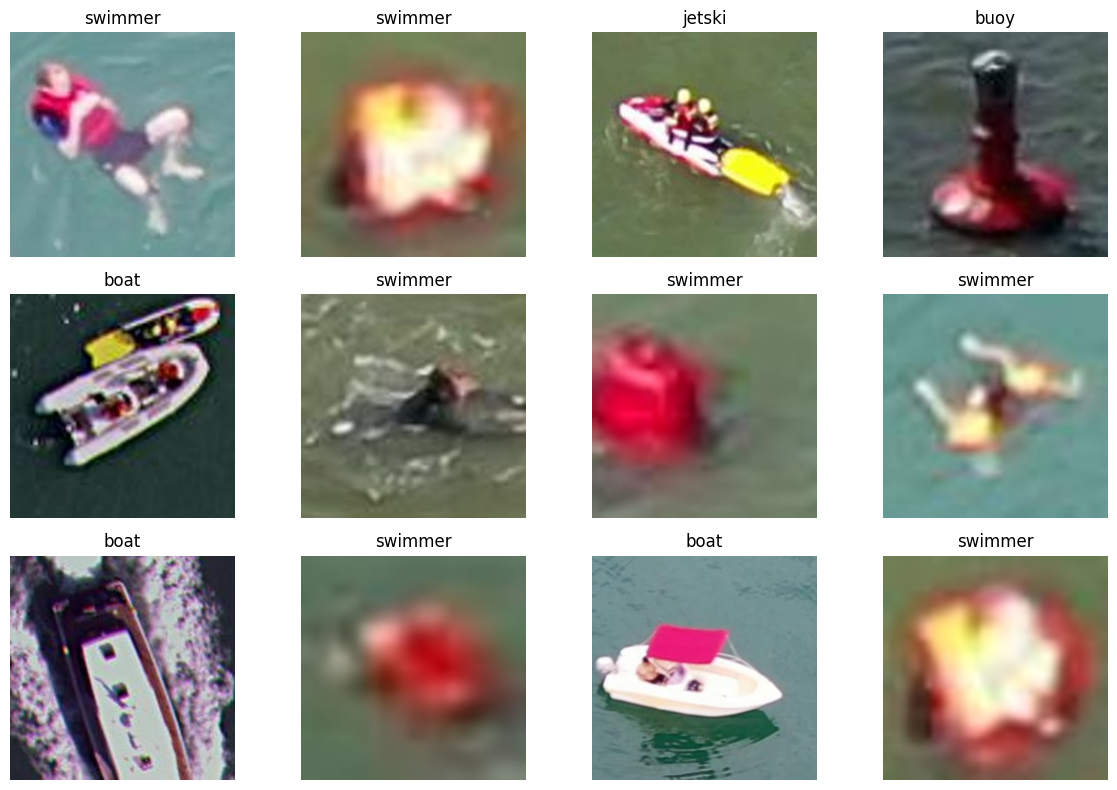

In [ ]:
#Step 6 — Visualize sample crops
import matplotlib.pyplot as plt
import random

def show_random_crops(split="train", n=12):
    crop_paths = list((OUT_ROOT / split).rglob("*.jpg"))

    if len(crop_paths) == 0:
        print("No crops found.")
        return

    sample_paths = random.sample(crop_paths, min(n, len(crop_paths)))

    plt.figure(figsize=(12, 8))

    for i, p in enumerate(sample_paths):
        img = Image.open(p).convert("RGB")
        class_name = p.parent.name

        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_crops("train", n=12)

In [ ]:
from pathlib import Path
import yaml

yaml_path = Path("/content/raw_data/raw_data/SeaDronesSee.yaml")

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

data_yaml

{'train': './data/train',
 'val': './data/val',
 'test': './data/test',
 'nc': 7,
 'names': ['ignored',
  'swimmer',
  'boat',
  'jetski',
  'life_saving_appliances',
  'buoy']}

In [ ]:
print(data_yaml.get("names"))

['ignored', 'swimmer', 'boat', 'jetski', 'life_saving_appliances', 'buoy']


In [ ]:
from pathlib import Path
from collections import Counter

DATA_ROOT = Path("/content/raw_data/raw_data")

def count_class_ids(split):
    labels_dir = DATA_ROOT / split
    counter = Counter()

    for label_path in labels_dir.rglob("*.txt"):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(float(parts[0]))
                    counter[class_id] += 1

    return counter

train_counter = count_class_ids("train")
val_counter = count_class_ids("val")

print("Train class IDs:", train_counter)
print("Val class IDs:", val_counter)

Train class IDs: Counter({1: 74192, 2: 26044, 5: 8778, 3: 4660, 4: 1846})
Val class IDs: Counter({1: 6206, 2: 2214, 5: 560, 4: 330, 3: 320})
